Training period: 2015-01-04 to 2018-10-07
Test period:     2018-10-14 to 2020-10-04

Forecast accuracy on test set
            model    MAE   RMSE   MASE   Bias
0   Feature model  2.041  2.723  1.525  1.495
1  Seasonal naive  2.063  2.672  1.541  1.441
2         SARIMAX  3.205  3.927  2.395  3.040
3           Naive  3.783  4.459  2.827 -0.882
4            Mean  3.789  4.397  2.831  0.481
5           Drift  4.340  5.118  3.243  1.007


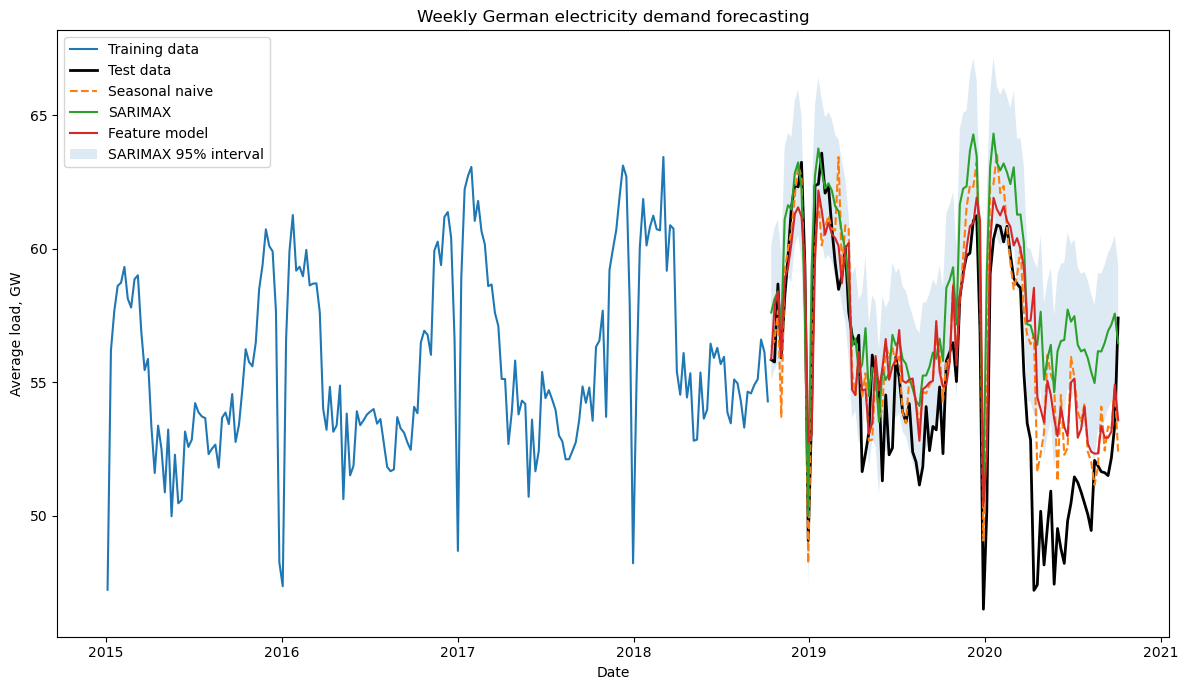

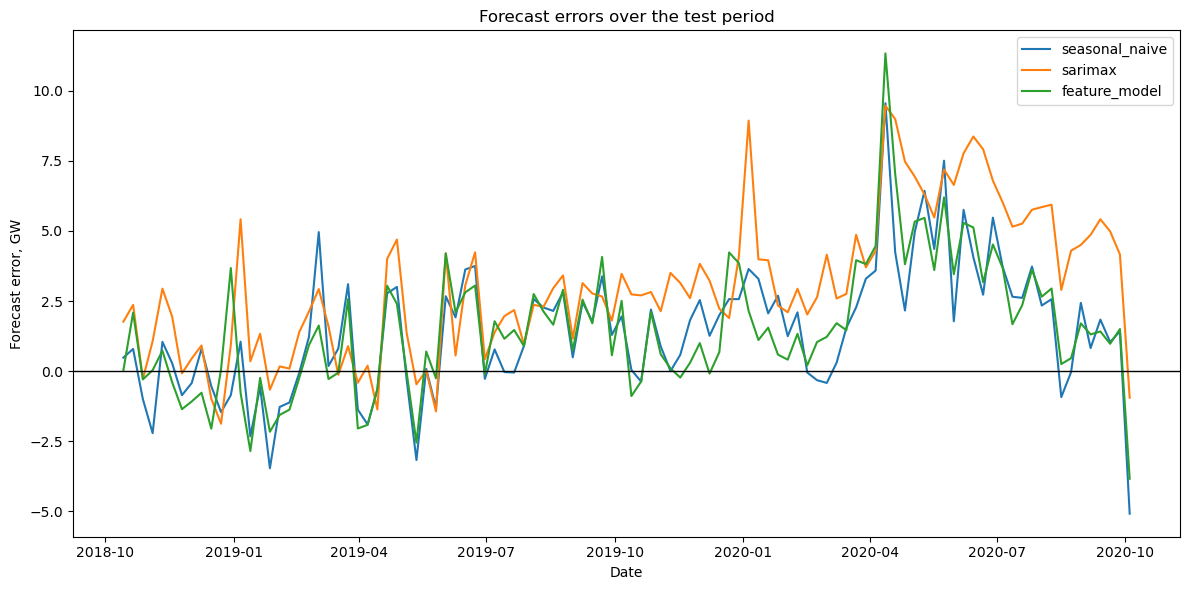

In [1]:
# ============================================================
# Advanced Research Topics Assignment 1:  Time series case study:
# Forecasting weekly German electricity demand
#
# Data: Open Power System Data, Germany electricity load
# Models:
#   1. Simple benchmarks
#   2. SARIMAX
#   3. Feature-based machine learning

# This is an initial workflow for the analyis. The finished pipeline will be significantly more complex than this.
# If you submit a minimally modified version of this pipeline then you will not receive a good grade.

# ============================================================

# Core
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Classical models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Feature-based model
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional Bayesian model
# pip install pymc arviz
#import pymc as pm
#import arviz as az

# Optional N-BEATS model
# pip install "u8darts[torch]"
#from darts import TimeSeries
#from darts.models import NBEATSModel


RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)


# ------------------------------------------------------------
# 1. Download and prepare Germany electricity load
# ------------------------------------------------------------

url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df = pd.read_csv(
    url,
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"]
)

df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw"
})

df = df.set_index("date").sort_index()

load = df["load_mw"].astype(float)
load = load[load.notna()]

# Restrict to modern period
load = load["2015-01-01":]

# Weekly average load in GW
weekly = load.resample("W").mean() / 1000.0
weekly = weekly.asfreq("W")
weekly = weekly.interpolate("time")
weekly.name = "load_gw"

y = weekly.copy()


# ------------------------------------------------------------
# 2. Train-test split
# ------------------------------------------------------------

test_weeks = 104          # two-year forecast horizon
train = y.iloc[:-test_weeks]
test = y.iloc[-test_weeks:]

print(f"Training period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()}")


# ------------------------------------------------------------
# 3. Evaluation utilities
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)


def mase(y_true, y_pred, y_train, seasonality=52):
    """
    Mean absolute scaled error.
    Uses seasonal naive in-sample errors as the scaling denominator.
    """
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate_forecast(name, y_true, y_pred, y_train):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }


results = []


# ------------------------------------------------------------
# 4. Simple benchmark models
# ------------------------------------------------------------

h = len(test)

# 4.1 Mean forecast
mean_forecast = pd.Series(train.mean(), index=test.index)

# 4.2 Last observation carried forward
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

# 4.3 Seasonal naive forecast: same week last year
seasonal_naive_values = []
history = train.copy()

for date in test.index:
    seasonal_date = date - pd.DateOffset(weeks=52)

    if seasonal_date in history.index:
        seasonal_naive_values.append(history.loc[seasonal_date])
    else:
        seasonal_naive_values.append(history.iloc[-52])

    # recursive update with actual test value, for one-step-ahead style benchmark
    history.loc[date] = test.loc[date]

seasonal_naive_forecast = pd.Series(seasonal_naive_values, index=test.index)

# 4.4 Drift forecast
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_forecast = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index
)

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast,
}

for name, pred in benchmark_forecasts.items():
    results.append(evaluate_forecast(name, test, pred, train))


# ------------------------------------------------------------
# 5. SARIMAX model

# this is a very simplified version of the modleling tasks

# ------------------------------------------------------------

sarimax = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarimax_fit = sarimax.fit(disp=False)

sarimax_fc = sarimax_fit.get_forecast(steps=h)
sarimax_mean = sarimax_fc.predicted_mean
sarimax_ci95 = sarimax_fc.conf_int(alpha=0.05)
sarimax_ci80 = sarimax_fc.conf_int(alpha=0.20)

sarimax_mean.index = test.index
sarimax_ci95.index = test.index
sarimax_ci80.index = test.index

results.append(evaluate_forecast("SARIMAX", test, sarimax_mean, train))


# ------------------------------------------------------------
# 6. Feature-based machine-learning model
# ------------------------------------------------------------

def make_features(series, max_lag=52):
    """
    Create a supervised learning table from a weekly time series.
    Includes lag, rolling, calendar, and Fourier features.
    """
    df_feat = pd.DataFrame({"y": series})

    # Lag features
    for lag in [1, 2, 4, 8, 13, 26, 52]:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)

    # Rolling features
    df_feat["roll_mean_4"] = df_feat["y"].shift(1).rolling(4).mean()
    df_feat["roll_mean_13"] = df_feat["y"].shift(1).rolling(13).mean()
    df_feat["roll_mean_52"] = df_feat["y"].shift(1).rolling(52).mean()

    # Calendar features
    week = df_feat.index.isocalendar().week.astype(int)
    df_feat["week"] = week
    df_feat["year"] = df_feat.index.year

    # Fourier seasonal features for annual weekly seasonality
    for k in range(1, 4):
        df_feat[f"sin_{k}"] = np.sin(2 * np.pi * k * week / 52)
        df_feat[f"cos_{k}"] = np.cos(2 * np.pi * k * week / 52)

    return df_feat.dropna()


supervised = make_features(y)

train_supervised = supervised.loc[supervised.index <= train.index[-1]]
test_supervised = supervised.loc[supervised.index >= test.index[0]]

X_train = train_supervised.drop(columns="y")
y_train_ml = train_supervised["y"]

X_test = test_supervised.drop(columns="y")
y_test_ml = test_supervised["y"]

gbr = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=15,
    random_state=RANDOM_STATE,
)

gbr.fit(X_train, y_train_ml)

ml_forecast = pd.Series(
    gbr.predict(X_test),
    index=y_test_ml.index,
    name="Feature model"
)

results.append(evaluate_forecast("Feature model", y_test_ml, ml_forecast, train))




# ------------------------------------------------------------
#  Results table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("MASE").reset_index(drop=True)

print("\nForecast accuracy on test set")
print(results_df.round(3))


# ------------------------------------------------------------
#  Plot forecasts
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.plot(train.index, train, label="Training data", linewidth=1.5)
plt.plot(test.index, test, label="Test data", linewidth=2, color="black")

plt.plot(test.index, seasonal_naive_forecast, label="Seasonal naive", linestyle="--")
plt.plot(test.index, sarimax_mean, label="SARIMAX")
plt.plot(test.index, ml_forecast.reindex(test.index), label="Feature model")


# SARIMAX uncertainty bands
plt.fill_between(
    test.index,
    sarimax_ci95.iloc[:, 0],
    sarimax_ci95.iloc[:, 1],
    alpha=0.15,
    label="SARIMAX 95% interval",
)

plt.title("Weekly German electricity demand forecasting")
plt.ylabel("Average load, GW")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
#  Residual diagnostics for selected models
# ------------------------------------------------------------

diagnostics = pd.DataFrame({
    "actual": test,
    "seasonal_naive": seasonal_naive_forecast,
    "sarimax": sarimax_mean,
    "feature_model": ml_forecast.reindex(test.index),
})

for col in diagnostics.columns[1:]:
    diagnostics[f"{col}_error"] = diagnostics[col] - diagnostics["actual"]

error_cols = [c for c in diagnostics.columns if c.endswith("_error")]

plt.figure(figsize=(12, 6))
for col in error_cols:
    plt.plot(diagnostics.index, diagnostics[col], label=col.replace("_error", ""))

plt.axhline(0, color="black", linewidth=1)
plt.title("Forecast errors over the test period")
plt.ylabel("Forecast error, GW")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()